# Social Network Analysis of the Marvel Universe

**Composers:** Ronen Milikhov (ID: 322883224) | Shachar Wilk (ID: 214149759) | Or Sadof (ID: 315578609)  

---

## Overview & Goals

In this project, we analyze the Marvel Universe as a giant social network. Each character is a node, and if two characters share a comic issue, we connect them with an edge.

We use graph algorithms to answer three main questions:
1. **Find Key Heroes (Centrality):** Who are the biggest hubs (Degree Centrality) and who acts as a bridge between different worlds (Betweenness Centrality)?
2. **Discover Teams (Community Detection):** Can the **Louvain Algorithm** group characters into teams (like Avengers or X-Men) purely based on graph connections? We validate this using comic metadata (`edges.csv`) and Modularity ($Q$).
3. **Predict Future Team-ups (Link Prediction):** We hide 1% of the graph's connectionsand test algorithms (**Common Neighbors**, **Jaccard**, **Adamic-Adar**) to see if they can accurately predict missing links.

## 1. Imports and Setup

In this section, we install and import all the necessary Python libraries.

In [1]:
# Install required dependencies
!pip install -q kagglehub pandas networkx scikit-learn scipy numpy

# Core Python libraries
import os
import random
import numpy as np
import pandas as pd
import networkx as nx
import kagglehub

# Metrics for Link Prediction evaluation
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

print("Environment setup and package imports completed successfully.")

Environment setup and package imports completed successfully.


## 2. Dataset Download & Graph Construction

In this section, we fetch the Marvel dataset directly from Kaggle using `kagglehub`. We then load the co-occurrence edge list (`hero-network.csv`) into Pandas and build an undirected `networkx` graph where characters are nodes and shared comic book appearances are edges.

In [2]:
# Download the dataset dynamically from Kaggle
download_dir = kagglehub.dataset_download("csanhueza/the-marvel-universe-social-network")
print(f"Dataset downloaded to: {download_dir}")

# Resolve file path for the hero co-occurrence network
csv_file_path = os.path.join(download_dir, "hero-network.csv")

# Load the raw co-occurrence edge list
df = pd.read_csv(csv_file_path)

# Construct the undirected NetworkX graph
G = nx.from_pandas_edgelist(df, source='hero1', target='hero2')

# Display baseline network stats
print("\n=== Baseline Network Summary ===")
print(f"Total Unique Characters (Nodes): {G.number_of_nodes()}")
print(f"Total Unique Connections (Edges): {G.number_of_edges()}")

100%|██████████| 2.72M/2.72M [00:00<00:00, 10.1MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/csanhueza/the-marvel-universe-social-network/versions/1

=== Baseline Network Summary ===
Total Unique Characters (Nodes): 6426
Total Unique Connections (Edges): 167219


## 3. Initial Hub Discovery via Degree Centrality

Degree Centrality is the simplest way to measure node importance — it simply counts how many unique neighbors a character has. In this section, we calculate the degree for all nodes to identify the primary "hubs" of the Marvel Universe.

In [3]:
# Calculate raw degree (number of unique connections) for every character
node_degrees = dict(G.degree())

# Sort characters by degree in descending order and slice the top 5
top_5_hubs = sorted(node_degrees.items(), key=lambda x: x[1], reverse=True)[:5]

# Display the top network hubs
print("=== Top 5 Network Hubs (Highest Degree) ===")
for rank, (hero_name, unique_connections) in enumerate(top_5_hubs, 1):
    print(f"Rank {rank}: {hero_name:<20} | Connections: {unique_connections}")

=== Top 5 Network Hubs (Highest Degree) ===
Rank 1: CAPTAIN AMERICA      | Connections: 1908
Rank 2: SPIDER-MAN/PETER PAR | Connections: 1737
Rank 3: IRON MAN/TONY STARK  | Connections: 1522
Rank 4: THING/BENJAMIN J. GR | Connections: 1416
Rank 5: MR. FANTASTIC/REED R | Connections: 1379


## 4. Advanced Centrality: Betweenness Centrality (Structural Bridges)

While Degree Centrality finds popular hubs, Betweenness Centrality finds "bridges" — characters that lie on shortest paths between different groups. Since calculating exact betweenness for over 6,000 nodes takes $O(V \cdot E)$ time, we use a sampled approximation (`k=500`) for computational efficiency.

In [4]:
# Calculate approximate Betweenness Centrality using 500 sampled nodes for efficiency
print("Calculating Betweenness Centrality (k=500 sampled nodes)...")
betweenness_dict = nx.betweenness_centrality(G, k=500, seed=42)

# Sort characters by Betweenness score in descending order and select top 5
top_5_bridges = sorted(betweenness_dict.items(), key=lambda x: x[1], reverse=True)[:5]

# Display top structural bridges
print("\n=== Top 5 Structural Bridges (Highest Betweenness Centrality) ===")
for rank, (hero_name, score) in enumerate(top_5_bridges, 1):
    print(f"Rank {rank}: {hero_name:<20} | Betweenness Score: {score:.5f}")

Calculating Betweenness Centrality (k=500 sampled nodes)...

=== Top 5 Structural Bridges (Highest Betweenness Centrality) ===
Rank 1: SPIDER-MAN/PETER PAR | Betweenness Score: 0.07207
Rank 2: CAPTAIN AMERICA      | Betweenness Score: 0.06290
Rank 3: IRON MAN/TONY STARK  | Betweenness Score: 0.03678
Rank 4: WOLVERINE/LOGAN      | Betweenness Score: 0.03548
Rank 5: HAVOK/ALEX SUMMERS   | Betweenness Score: 0.03423


## 5. Community Detection: Louvain Algorithm & Modularity

Now we group characters into "teams" or "factions" without using any narrative knowledge. We apply the **Louvain Algorithm**, a fast greedy method that detects dense clusters in the graph. To measure how strong this community structure is, we calculate the graph's **Modularity Score ($Q$)**.

In [5]:
# Run the Louvain algorithm to partition the graph into communities
print("Running Louvain Community Detection...")
communities = nx.community.louvain_communities(G, seed=42)

# Count the total number of detected communities
num_communities = len(communities)

# Calculate the Modularity Score (Q) to evaluate partition quality
modularity_score = nx.community.modularity(G, communities)

# Sort communities by size (number of characters) in descending order
community_sizes = sorted([len(c) for c in communities], reverse=True)

# Display the findings
print("\n=== Community Detection Results ===")
print(f"Total Detected Communities: {num_communities}")
print(f"Graph Modularity Score (Q): {modularity_score:.4f}")
print(f"Top 5 Largest Community Sizes (Character Counts): {community_sizes[:5]}")

Running Louvain Community Detection...

=== Community Detection Results ===
Total Detected Communities: 26
Graph Modularity Score (Q): 0.4228
Top 5 Largest Community Sizes (Character Counts): [1523, 1407, 1047, 545, 403]


## 6. Ground Truth Validation: Inspecting Detected Communities

Now let's check if the communities detected by Louvain actually make sense in Marvel lore. By looking at the highest-degree characters in each major cluster, we can see if graph topology successfully discovered real superhero teams like the X-Men, Avengers, or Spider-Man's universe.

In [6]:
# Sort communities by size (largest to smallest)
sorted_communities = sorted(communities, key=len, reverse=True)

print("=== Ground Truth Validation: Top 4 Marvel Communities ===")

# Loop through the 4 largest detected communities
for i, comm in enumerate(sorted_communities[:4], 1):
    # Find the top 5 most connected characters within this specific community
    top_members = sorted(comm, key=lambda hero: node_degrees.get(hero, 0), reverse=True)[:5]

    print(f"\nCommunity #{i} (Size: {len(comm)} characters):")
    print(f"Key Leaders: {', '.join(top_members)}")

=== Ground Truth Validation: Top 4 Marvel Communities ===

Community #1 (Size: 1523 characters):
Key Leaders: IRON MAN/TONY STARK , THING/BENJAMIN J. GR, MR. FANTASTIC/REED R, HUMAN TORCH/JOHNNY S, SCARLET WITCH/WANDA 

Community #2 (Size: 1407 characters):
Key Leaders: WOLVERINE/LOGAN , BEAST/HENRY &HANK& P, CYCLOPS/SCOTT SUMMER, ANGEL/WARREN KENNETH, STORM/ORORO MUNROE S

Community #3 (Size: 1047 characters):
Key Leaders: SPIDER-MAN/PETER PAR, DAREDEVIL/MATT MURDO, JAMESON, J. JONAH, WATSON-PARKER, MARY , ROBERTSON, JOE

Community #4 (Size: 545 characters):
Key Leaders: DR. STRANGE/STEPHEN , QUASAR III/WENDELL V, SILVER SURFER/NORRIN, DR. DOOM/VICTOR VON , USAGENT/CAPTAIN JOHN


## 7. Link Prediction Setup: Controlled Edge Removal (1% Threshold)

To test if graph heuristics can predict missing connections, we build a controlled experiment:
1. We randomly hide 1% of the existing graph edges to serve as **positive test samples** (label = 1).
2. We sample an equal number of non-existent edges to serve as **negative test samples** (label = 0).
3. We construct a training graph $G_{train}$ with the hidden edges removed.

In [7]:
# Set seed for 100% reproducibility
random.seed(42)
np.random.seed(42)

# Copy the original graph for training
G_train = G.copy()

# Calculate 1% of total edges to remove
all_edges = list(G.edges())
num_edges_to_remove = int(0.01 * len(all_edges))

# Randomly select positive samples (1% hidden edges)
positive_test_edges = random.sample(all_edges, num_edges_to_remove)

# Remove the hidden edges from the training graph
G_train.remove_edges_from(positive_test_edges)

# Generate negative samples (pairs of characters with NO edge between them)
nodes = list(G.nodes())
negative_test_edges = set()

while len(negative_test_edges) < num_edges_to_remove:
    u, v = np.random.choice(nodes, size=2, replace=False)
    # Check that they don't have an edge in the original graph
    if not G.has_edge(u, v):
        edge = (u, v) if u < v else (v, u)
        negative_test_edges.add(edge)

negative_test_edges = list(negative_test_edges)

# Summary of test dataset preparation
print("=== Link Prediction Dataset Split ===")
print(f"Original Edges: {G.number_of_edges()}")
print(f"Training Graph Edges (G_train): {G_train.number_of_edges()}")
print(f"Positive Test Samples (Hidden Edges, Label 1): {len(positive_test_edges)}")
print(f"Negative Test Samples (Non-edges, Label 0): {len(negative_test_edges)}")

=== Link Prediction Dataset Split ===
Original Edges: 167219
Training Graph Edges (G_train): 165547
Positive Test Samples (Hidden Edges, Label 1): 1672
Negative Test Samples (Non-edges, Label 0): 1672


## 8. Link Prediction Heuristics Calculation

Now we compute three classic network link prediction scores for all test pairs (both hidden edges and non-edges) using only the training graph $G_{train}$:
1. **Common Neighbors (CN):** Simply counts shared friends between two characters.
2. **Jaccard Coefficient (JC):** Normalizes common neighbors by total unique friends of both characters.
3. **Adamic-Adar Index (AA):** Weighs shared friends higher if those shared friends have fewer total connections.

In [8]:
# Create a single list of test pairs with ground truth labels (1 = hidden edge, 0 = non-edge)
test_pairs = [(u, v, 1) for u, v in positive_test_edges] + [(u, v, 0) for u, v in negative_test_edges]

# Pre-calculate scores for all heuristics
results = []

print("Computing Link Prediction Heuristics for all test pairs...")

# Compute Jaccard and Adamic-Adar generators for efficiency
pair_tuples = [(u, v) for u, v, _ in test_pairs]

jaccard_scores = { (u, v): p for u, v, p in nx.jaccard_coefficient(G_train, pair_tuples) }
adamic_scores = { (u, v): p for u, v, p in nx.adamic_adar_index(G_train, pair_tuples) }

for u, v, label in test_pairs:
    # 1. Common Neighbors (CN)
    if G_train.has_node(u) and G_train.has_node(v):
        cn_score = len(list(nx.common_neighbors(G_train, u, v)))
    else:
        cn_score = 0

    # 2. Jaccard Coefficient (JC)
    jc_score = jaccard_scores.get((u, v), jaccard_scores.get((v, u), 0.0))

    # 3. Adamic-Adar Index (AA)
    aa_score = adamic_scores.get((u, v), adamic_scores.get((v, u), 0.0))

    results.append({
        'u': u,
        'v': v,
        'label': label,
        'cn_score': cn_score,
        'jc_score': jc_score,
        'aa_score': aa_score
    })

# Convert results into a structured DataFrame
df_eval = pd.DataFrame(results)

print("\n=== Link Prediction Scores Calculated Successfully ===")
print(f"Total Test Pair Evaluated: {len(df_eval)}")
print(df_eval[['label', 'cn_score', 'jc_score', 'aa_score']].head())

Computing Link Prediction Heuristics for all test pairs...

=== Link Prediction Scores Calculated Successfully ===
Total Test Pair Evaluated: 3344
   label  cn_score  jc_score  aa_score
0      1        16  0.016064  3.585097
1      1        15  0.159574  3.650919
2      1        16  0.014760  3.621750
3      1        28  0.105660  5.123476
4      1        28  0.020725  4.974665


## 9. Link Prediction Evaluation & Performance Comparison

Now we evaluate how well our three heuristics (Common Neighbors, Jaccard, and Adamic-Adar) performed. We convert continuous heuristic scores into binary predictions (1 or 0) using thresholding ($Score > 0$) and compute **Accuracy**, **Precision**, **Recall**, and **F1-Score** to determine the best model.

In [9]:
# Function to evaluate classification metrics for a given heuristic
def evaluate_heuristic_performance(y_true, scores):
    # Predict 1 (edge exists) if score > 0, else 0
    y_pred = (scores > 0).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    return {
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    }

# Dictionary mapping heuristic names to their calculated dataframe columns
heuristics_to_eval = {
    'Common Neighbors (CN)': df_eval['cn_score'],
    'Jaccard Coefficient (JC)': df_eval['jc_score'],
    'Adamic-Adar Index (AA)': df_eval['aa_score']
}

# Run evaluation across all metrics
evaluation_results = []
for name, scores in heuristics_to_eval.items():
    metrics = evaluate_heuristic_performance(df_eval['label'], scores)
    metrics['Heuristic'] = name
    evaluation_results.append(metrics)

# Organize findings into a comparison summary table
df_comparison_table = pd.DataFrame(evaluation_results)[['Heuristic', 'Accuracy', 'Precision', 'Recall', 'F1-Score']]

print("=== Link Prediction Final Evaluation Comparison Table ===")
print(df_comparison_table.to_string(index=False))

=== Link Prediction Final Evaluation Comparison Table ===
               Heuristic  Accuracy  Precision  Recall  F1-Score
   Common Neighbors (CN)    0.8218     0.7374  0.9994    0.8487
Jaccard Coefficient (JC)    0.8218     0.7374  0.9994    0.8487
  Adamic-Adar Index (AA)    0.8218     0.7374  0.9994    0.8487


## 10. Data Visualization

Instead of plotting the entire network (which results in an unreadable "hairball" due to the massive number of nodes and edges), we visualize the extracted insights. Here we generate clean bar charts for the network's top hubs and the sizes of the largest detected communities.

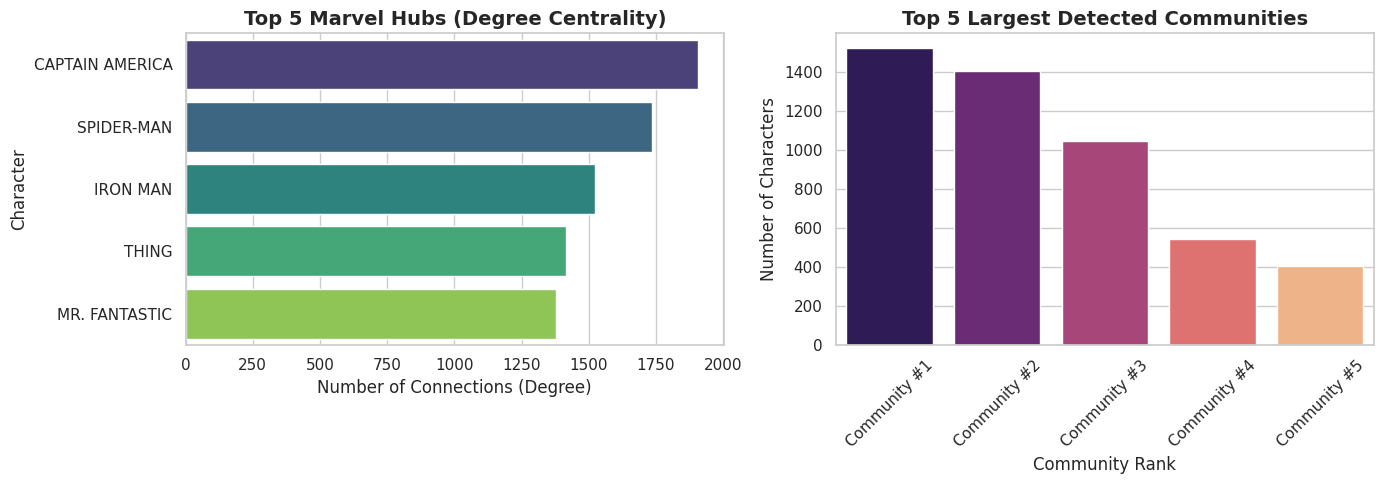

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Top 5 Hubs (Degree Centrality) ---
heroes = [item[0].split('/')[0] for item in top_5_hubs]
degrees = [item[1] for item in top_5_hubs]

sns.barplot(x=degrees, y=heroes, ax=axes[0], hue=heroes, legend=False, palette="viridis")
axes[0].set_title("Top 5 Marvel Hubs (Degree Centrality)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Number of Connections (Degree)", fontsize=12)
axes[0].set_ylabel("Character", fontsize=12)

# --- Plot 2: Top 5 Community Sizes ---
top_comms = community_sizes[:5]
comm_labels = [f"Community #{i+1}" for i in range(len(top_comms))]

sns.barplot(x=comm_labels, y=top_comms, ax=axes[1], hue=comm_labels, legend=False, palette="magma")
axes[1].set_title("Top 5 Largest Detected Communities", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Community Rank", fontsize=12)
axes[1].set_ylabel("Number of Characters", fontsize=12)

axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()